# Evaluating performance of variant growth rate inference of FGA and GARW models

## Notebook Overview

### Objectives
* Define a way to compare model Rt inference with simulated observations 
* Zoom-in on on a well-performing window and ones that contradict biological intuition despite decent performance metrics, as well as those that just perform poorly
* Compare ability of FGA and GARW models to estimate variant growth rates across entire simulation

### Methods

**Growth Rate Transformation Framework:**
* Load epidemic growth rates ($r_{\text{model},v}(t)$) inferred alongside effective reproductive numbers ($R_v(t)$) by `evofr`, if not available, infer using the Euler-Lokta equation, the gamma-distributed generation times, and the `evofr` inferred $R_v(t)$ values
* Calculate empirical growth rates ($r_{\text{data},v}(t)$) from variant-specific incidence data using log-difference of smoothed variant frequencies and case counts
* Add and apply consistent filtering criteria for variants to be included in growth rate analysis, including: minimum smoothed sequence count (10) and minimum variant frequency (0.01) to ensure reliable estimates
* Use univariate spline smoothing (s=1.0, order=3) to reduce noise in variant frequency data (or counts if desired)

**Performance Metrics:**
- **Pearson correlation**: Measures linear relationship between model and empirical growth rates
- **Mean Absolute Error (MAE)**: Quantifies average magnitude of prediction errors
- **Normalized MAE (nMAE)**: MAE divided by the largest $r_{\text{data},v}(t)$ in the window
- **Root Mean Square Error (RMSE)**: Penalizes larger errors more heavily
- **Overestimation rate**: Fraction of time points where $r_{\text{model},v}(t)$ overestimates $r_{\text{data},v}(t)$ by at least some tolerance threshold $\epsilon = 1e-3$
- **Sign disagreement rate**: Frequency of disagreement on growth direction (positive/negative)


### Results

**Individual Window Analysis:**
1. **Combined dynamics plots** (`plot_analysis_window_with_variant_counts`): Four-panel visualization showing variant frequencies, sampled sequences, fitness trajectories, and $R_v(t)$ estimates for specific training windows
2. **Growth rate comparison plots** (`plot_growth_rate_dynamics`): Direct comparison of $r_{\text{model}}$ vs $r_{\text{data}}$ with variant-specific trajectories and frequency-based filtering (note that smoothed frequencies shown are smoothed for calculations and not the model inferred values)

**Aggregate Performance Analysis:**
1. **Distribution plots**: Box plots comparing correlation, MAE, RMSE, and overestimation rates between FGA/GARW models across geographic regions
2. **Variant-level error tracking**: Scatter plots showing average MAE and overestimation rates for individual variants across all training windows, with outliers labeled
3. **Outlier identification**: Tables highlighting training windows with extreme performance metrics (lowest correlations, highest MAE values) averaged across all variants

**Deep-dive Investigations:**
* Detailed growth rate dynamics for windows with high overestimation rates (≥0.8) or high MAE values (≥0.15)
* Side-by-side comparisons of variant metrics between different regions and time periods

### Conclusion
* Overall, windows that perform poorly with MAE tend to have sparse sequences and or case counts over most of the training window
  * Sometimes, we see an artificial "hump" in the model inferred growth rates, perhaps an artifact of these models and how they're formulated?
  * Sometimes, models infer a pretty big jump in growth rates in a very short time window, even if the emperical data disagrees
* Overestimation rate is a more fuzzy metric, and more difficult to justify using, but it seems to be pretty good at flagging windows that may have artificial "humps" if we actually care about investigating the mechanisms underlying them a bit more -- but for the purpose of the paper, perhaps it's best to just focus on MAE going forward...
* GARW models seem to just do a bit better on this task when compared to FGA models on this simulated dataset

## Variant growth Rate Calculations and Comparrisons using Euler-Lotka Method

### Quick overview
The Euler-Lotka equation provides a way to calculate growth rates based on reproduction numbers and generation time distributions. This approach is particularly useful for infectious disease modeling as it connects the effective reproduction number (Rt) with the exponential growth rate (r).

In the Fixed Growth Advantage (FGA) model, each variant has its own multiplicative growth factor $\delta_v$ that scales a variant-agnostic effective reproduction number $R_t$:

$$R_v(t) = \delta_v \cdot R_t$$

The Growth Advantage Random Walk (GARW) model allows variant growth advantages to vary smoothly over time, with each variant's effective reproduction number following a random walk prior:

$$R_v(t) \sim \mathcal{N}(R_v(t-1), \sigma^2)$$

The Euler-Lotka equation establishes the relationship between the effective reproduction number ($R_v(t)$) and the exponential growth rate ($r_v(t)$) accounting for the generation time distribution. 

The equation looks like this:

$$ \int_{0}^{\infty} e^{-r\tau} R_0 g(\tau)\,d\tau = 1 $$

Where:
* $r$ is the epidemic growth rate
* $\tau$ is a possible generation time
* $R_0 g(\tau)\,d\tau$ can be interpreted as the average numebr of **new** infections caused by our initial host at generation time $\tau$ (i.e., think between a time $t$ and $t + \tau$)
* $e^{-r\tau}$ is the "discount" of new cases accumulated during the generation time (keeps us from double counting infections I believe)


### Derivation of $r_{\text{model},v}(t_i)$ for our use case
Notice that this is actually $M_g(-r)$: MGF for $g(\tau)$, evaluated at $-r$, and then multiplied by $R_0$.

So we can now re-write this as $$R_0 \cdot M_g(-r) = 1$$

$$R_0 = \frac{1}{M_g(-r)} $$

And for our $R_t$:

$$R_t = \frac{1}{M_g(-r)} $$

We have been using a gamma distribution with shape parameter $\alpha$ and scale parameter $\theta$ for generation time distribution. 
The MGF for this gamma distribution is:

$$M_g(x) = (1 - x \theta)^{-\alpha} \text{ for } x\theta < 1 $$

Evaluating for $-r`: 

$$ M_g(-r) = (1 + r \theta)^{-k\alpha}$$

And since $R_t = \frac{1}{M_g(-r)}$, we have: 

$$R_t = (1 + r\theta)^{\alpha} $$

This is essentially where Marlin's paper stops with the Gamma case...now, we'd like to get the variant growth rate $r$ -- so let's solve for that:

$$R^{1/\alpha}_t = 1 + r\theta $$

$$r = \frac{R^{1/\alpha} - 1}{\theta} $$

So now we have a relationship between $r$ and model inferred $R_t$ (let's add the t to $r$ now...)

$$r_{\text{model}}(t) = \frac{R_t^{1/\alpha} - 1}{\theta}$$

### Derivation of $r_{\text{data},v}(t_i)$ for our use case
We can then let $C_{d}(t_i)$ be the number of observed cases in location $d$ at time $t_i$.

We can calculate a smoothed growth rate estimate for the observed case counts:

$$r_{\text{data}}(t_i) = \frac{\ln(C_{d}(t_i)) - \ln(C_{d}(t_i - 1))}{\Delta t_i}  $$

If we'd like this metric to be variant-specific, we have to estimate the number of counts attributable to a variant $v$:

$$C_{v,d}(t_i) = C_d(t_i) \cdot f_{v,d}(t_i) $$

$$r_{\text{data},v}(t_i) = \frac{\ln(C_{v,d}(t_i)) - \ln(C_{v,d}(t_i - 1))}{\Delta t_i}  $$


### Big Idea

* With these two metrics in hand, we can more rigorously compare model $R_t$ inference to the variant-specific growth rates in a deme
* This allows us to side-step the mis-match of looking at the derivative of raw variant counts and comparing them to the value of Rt
* We can now calculate pearson correlation between these two things and have a clear idea of how well models are doing
* Training windows with few and/or sparse case counts may generate pretty noisy $r_{\text{data},v}(t_i)$ however
* Sequence and case counts are reported weekly, where model inference is daily, so we'll have to consolidate this a bit... we could just focus on reporting dates and ignore inference on the six days in between each one... Or possibly interpolate the rest of the week with whatever the value is for that week, etc.
* Univariate spline smoothing on variant count data since these can be a lot nosier than cases -- but maybe these should be smoothed too?

## Package Imports

In [1]:
# General imports
import glob
import json
import random
import sys
sys.path.append('..')

# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Antigen tools
from antigentools.plot import (
    plot_antigenic_space_by_clade, 
    plot_analysis_window_with_variant_counts,
    plot_growth_rate_dynamics,
    plot_observed_dynamics
)
from antigentools.utils import (
    get_deme_stats,
    get_outliers,
)
from antigentools.analysis import (
    calculate_variant_mae,
    evaluate_growth_rate_performance,
    get_filtered_growth_rates_df
)


# Static variables for consistent growth rate filtering across the notebook
CONNECT_GAPS = True # Whether to connect gaps in the growth rate data when plotting
MIN_SEGMENT_LENGTH = 3 # Minimum segment length to trust growth rate calculations
MIN_SEQUENCE_COUNT = 10  # Minimum smoothed sequence count to continue with growth rate calculations
MIN_VARIANT_FREQUENCY = 0.01  # Minimum variant frequency to trust growth rate to consider growth rate calculations
EPSILON = 1e-3  # Tolerance threshold for overestimation rate calculations

# NEW: Sequence count threshold filter (set to None to disable filtering)
MIN_TOTAL_SEQUENCES = 300  # e.g., 750 to require at least 750 total sequences per window
CONVERGENCE_THRESHOLD = 0.5  # Threshold for convergence diagnostics

print(f"Analysis configuration:")
print(f"  MIN_TOTAL_SEQUENCES filter: {MIN_TOTAL_SEQUENCES}")
print(f"  MIN_SEQUENCE_COUNT per variant: {MIN_SEQUENCE_COUNT}")
print(f"  MIN_VARIANT_FREQUENCY: {MIN_VARIANT_FREQUENCY}")
print(f"  EPSILON (overestimation tolerance): {EPSILON}")

Analysis configuration:
  MIN_TOTAL_SEQUENCES filter: 300
  MIN_SEQUENCE_COUNT per variant: 10
  MIN_VARIANT_FREQUENCY: 0.01
  EPSILON (overestimation tolerance): 0.001


/Users/zthornto/miniforge3/envs/antigen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load files and setup analysis

In [2]:
build = "flu-simulated-150k-samples-seq"
fitness_path = f"../data/{build}/antigen-outputs/pruned_variant_fitness.csv"
truth_set_dir = f"../data/{build}/time-stamped/truth/"
truth_seqs_df = pd.read_csv(f"{truth_set_dir}/seq_counts.tsv", sep="\t")
truth_cases_df = pd.read_csv(f"{truth_set_dir}/case_counts.tsv", sep="\t")
#fitness_df = pd.read_csv(fitness_path)

In [3]:
print(truth_seqs_df.head())
print(truth_cases_df.head())

         date  country  variant  sequences
0  2025-01-19    north        2        427
1  2025-01-19    south        2        248
2  2025-01-19  tropics        2       1247
3  2025-02-09    north        2          2
4  2025-02-09    south        2          1
         date  country  cases
0  2025-01-05    north      3
1  2025-01-05    south      3
2  2025-01-05  tropics      9
3  2025-01-11    north      4
4  2025-01-11    south      2


In [4]:
 # Small fonts for dense plots
small_fonts = {
    'title_fontsize': 14,
    'label_fontsize': 12,
    'tick_labelsize': 10,
    'legend_fontsize': 10,
    'legend_title_fontsize': 12
 }

  # Large fonts for presentations
presentation_fonts = {
    'title_fontsize': 28,
    'label_fontsize': 20,
    'tick_labelsize': 16,
    'legend_fontsize': 16,
    'legend_title_fontsize': 18
}

  # Default/medium fonts
default_fonts = {
    'title_fontsize': 18,
    'label_fontsize': 14,
    'tick_labelsize': 12,
    'legend_fontsize': 12,
    'legend_title_fontsize': 14
}

In [5]:
# Color palette for the different locations
deme_palette = {
    "tropics": "#3498db",  # Softer blue
    "north": "#e67e22",    # Warmer orange 
    "south": "#2ecc71"     # More vibrant green
}

In [6]:
color_map_path = f"../data/{build}/auspice/variant_color_map.tsv"
color_map_df = pd.read_csv(color_map_path, sep="\t")
color_map_df.head()

,TRAIT_TYPE,TRAIT_VALUE,HEX_CODE
0,clade_membership,0,#5400ff
1,clade_membership,1,#0074ff
2,clade_membership,2,#ee00ff
3,clade_membership,3,#00ff27
4,clade_membership,4,#08ff00


In [7]:
# Create a color map dictionary from the color_map_df
color_map = dict(zip(color_map_df['TRAIT_VALUE'], color_map_df['HEX_CODE']))
# String color map for plotting
color_map_str = {str(k): v for k, v in color_map.items()}
print(f"Created color map with {len(color_map)} entries")
print(f"Sample: {list(color_map.items())[:5]}")

Created color map with 30 entries
Sample: [(0, '#5400ff'), (1, '#0074ff'), (2, '#ee00ff'), (3, '#00ff27'), (4, '#08ff00')]


In [8]:
tips_path = f"../data/{build}/antigen-outputs/viruses.csv"
tips_df = pd.read_csv(tips_path)
tips_df.head()

,name,year,trunk,tip,mark,location,layout,nucleotideSequence,ag1,ag2,...,mds2,mds3,mds4,mds5,mds6,mds7,mds8,mds9,mds10,variant_seq
0,fc36fc6,0.0398,0,1,0,0,6473.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,14.1399,3.7169,...,-4.103361,-1.366872,4.236197,3.817122,4.197259,2.215421,-0.04355,0.212964,-3.596864,2
1,57df5be5,0.0398,0,1,0,0,6467.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,14.1399,3.7169,...,-4.103361,-1.366872,4.236197,3.817122,4.197259,2.215421,-0.04355,0.212964,-3.596864,2
2,47d2014e,0.0398,0,1,0,0,570.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,14.1399,3.7169,...,-4.103361,-1.366872,4.236197,3.817122,4.197259,2.215421,-0.04355,0.212964,-3.596864,2
3,3d52a63b,0.0398,0,1,1,1,744.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,14.1399,3.7169,...,-4.103361,-1.366872,4.236197,3.817122,4.197259,2.215421,-0.04355,0.212964,-3.596864,2
4,3418cd15,0.0398,0,1,0,1,6675.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,14.1399,3.7169,...,-4.103361,-1.366872,4.236197,3.817122,4.197259,2.215421,-0.04355,0.212964,-3.596864,2


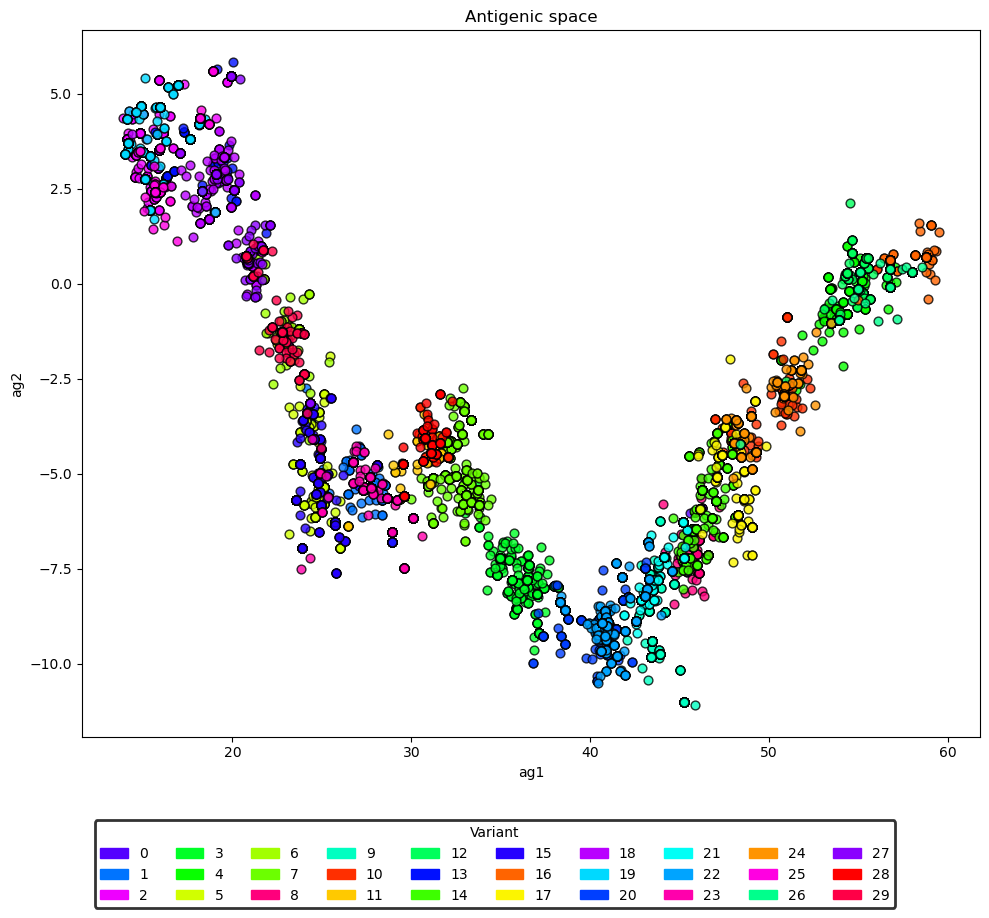

In [9]:
plot_antigenic_space_by_clade(
    tips_df, 
    color_map=color_map, 
    variant_col='variant_seq',
    figsize=(10, 8)
)

In [19]:
window_growth_rates_scores_path = f"../results/{build}/window_growth_rates.tsv"
variant_growth_rates_scores_path = f"../results/{build}/variant_growth_rates.tsv"
convergence_diagnostics_path = f"../results/{build}/vi_convergence_diagnostics.tsv"

# Load growth rate scores
window_growth_rate_errors_df = pd.read_csv(window_growth_rates_scores_path, sep="\t")
variant_growth_rate_errors_df = pd.read_csv(variant_growth_rates_scores_path, sep="\t")
convergence_diagnostics_df = pd.read_csv(convergence_diagnostics_path, sep="\t")

In [20]:
# Take a look at window growth rates
window_growth_rate_errors_df.head()

,pivot_date,model,location,correlation,mae,rmse,sign_disagreement_rate,overestimation_rate,n_seqs,n_cases,seq_entropy,case_entropy,seq_entropy_norm,case_entropy_norm
0,2026-04-01,FGA,north,0.933435,0.030271,0.033340,0.25,0.5,1010,1497,2.141201,4.276020,0.535300,0.750121
1,2026-10-01,FGA,north,0.971072,0.009008,0.012366,0.00,0.4,1305,2829,2.626133,4.924021,0.597892,0.863797
2,2027-04-01,FGA,north,0.847430,0.031623,0.046429,0.00,0.5,1983,21606,1.821842,4.132251,0.378970,0.724900
3,2027-10-01,FGA,north,NaN,NaN,NaN,NaN,NaN,1882,26073,1.710827,4.389237,0.348658,0.769982
4,2028-04-01,FGA,north,NaN,NaN,NaN,NaN,NaN,3451,6318,1.751656,3.547792,0.392798,0.622372


## Boxplot of window errors between models (high level perspective)

* Ensure that the metric column names in the dataframes produced by the model scoring scripts are the same (i.e. we have MAE in the frequency scoring script, but mae in the growth rates scoring script.)
* In the same way, let's also make sure the "location" or "country" columns in all dataframes get turned into "deme", and make sure all references in notebooks and scripts implement these changes as well
  

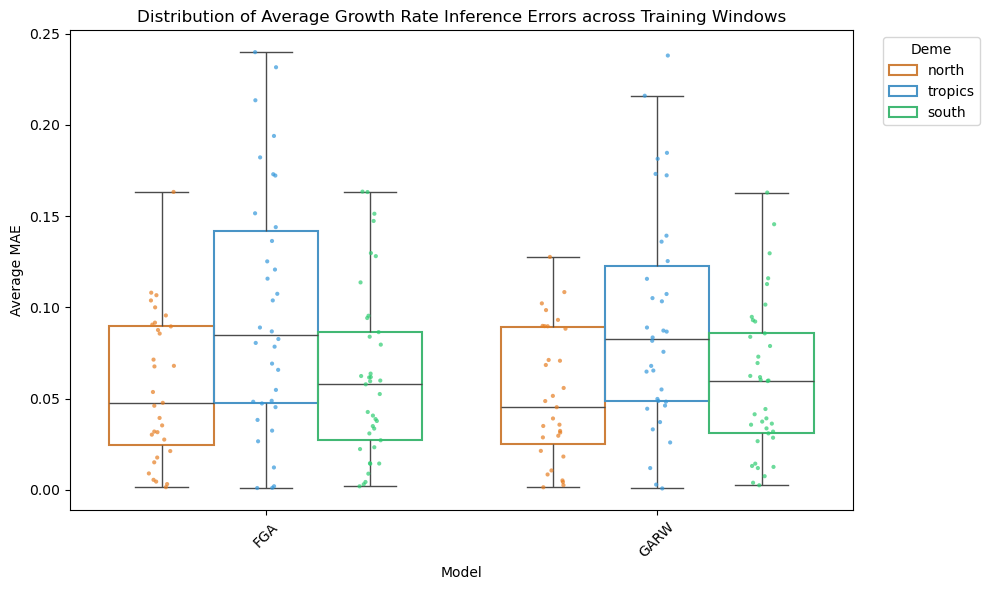

In [25]:
# Plot the distribution of errors by model -- NEW version
plt.figure(figsize=(10, 6))

# Create a copy of error_df with modified model names
error_df_plot = window_growth_rate_errors_df.copy()

# First create the boxplot
ax = sns.boxplot(data=error_df_plot, x='model', y='mae', hue='location',
                   hue_order=['north','tropics', 'south'],
                   palette=deme_palette,
                   showfliers=False
              )

for patch in ax.patches:
    edge_color = patch.get_facecolor()
    patch.set_facecolor('none')
    patch.set_edgecolor(edge_color)
    patch.set_linewidth(1.5)

# Overlay swarmplot with individual points
sns.stripplot(data=error_df_plot,x='model', y='mae',
                hue='location', hue_order=['north', 'tropics', 'south'], palette=deme_palette,
                dodge=True, jitter=True, size=3, alpha=0.7,
                legend=False  # Avoid duplicate legends
              )

# Customize axes labels and ticks
plt.ylabel('Average MAE')
plt.xlabel('Model')
plt.title('Distribution of Average Growth Rate Inference Errors across Training Windows')
plt.xticks(rotation=45)

# Update the legend
plt.legend(title='Deme',
bbox_to_anchor=(1.03, 1), loc='upper left')
plt.tight_layout()

plt.show()

## Variant-specific growth rate errors

I think this is the plot I'd like to use

In [22]:
variant_growth_rate_errors_df.head()

,variant,pivot_date,model,location,mae,normalized_mae,max_r_data,correlation,sign_disagreement_rate,overestimation_rate,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency
0,2,2026-04-01,FGA,north,0.030271,0.382198,0.079201,0.933435,0.25,0.5,4,691.0,690.172467,1.000000,0.810294,1.000000,0.865005
1,18,2026-04-01,FGA,north,0.038288,0.909746,0.042087,NaN,0.00,1.0,1,278.0,277.881405,0.996416,0.171320,0.996416,0.171320
2,19,2026-04-01,FGA,north,0.060683,0.918505,0.066067,NaN,0.00,0.0,1,14.0,13.723807,1.000000,0.631154,1.000000,0.631154
3,2,2026-10-01,FGA,north,0.009008,0.203507,0.044264,0.971072,0.00,0.4,5,681.0,680.119411,0.990000,0.881478,1.000000,0.976528
4,18,2026-10-01,FGA,north,0.018496,0.362872,0.050971,NaN,0.00,1.0,1,278.0,277.583289,0.996416,0.245300,0.996416,0.245300


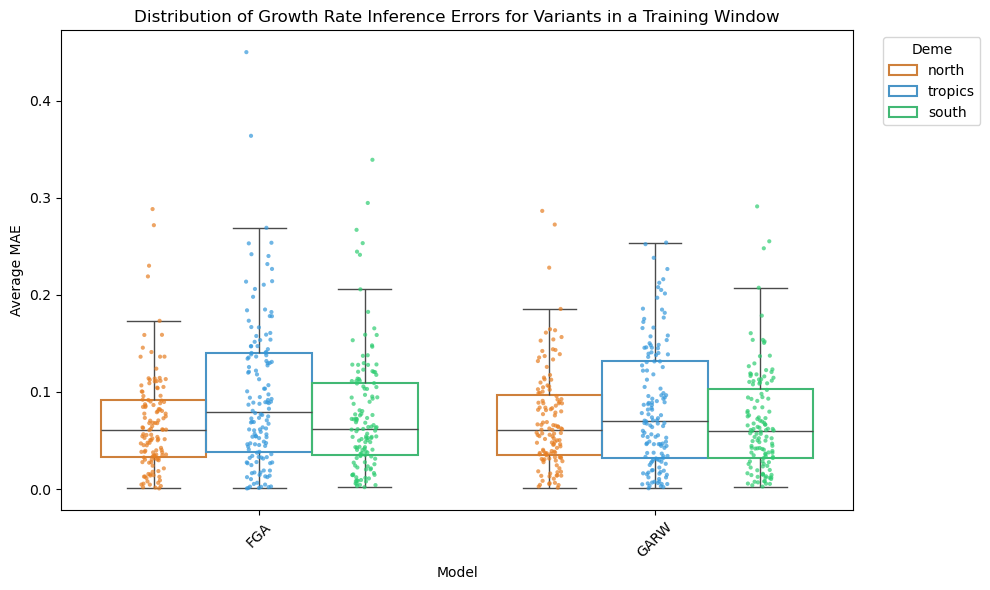

In [24]:
# Plot the distribution of errors by model -- NEW version
plt.figure(figsize=(10, 6))

# Create a copy of error_df with modified model names
error_df_plot = variant_growth_rate_errors_df.copy()

# First create the boxplot
ax = sns.boxplot(data=error_df_plot, x='model', y='mae', hue='location',
                   hue_order=['north','tropics', 'south'],
                   palette=deme_palette,
                   showfliers=False
              )

for patch in ax.patches:
    edge_color = patch.get_facecolor()
    patch.set_facecolor('none')
    patch.set_edgecolor(edge_color)
    patch.set_linewidth(1.5)

# Overlay swarmplot with individual points
sns.stripplot(data=error_df_plot,x='model', y='mae',
                hue='location', hue_order=['north', 'tropics', 'south'], palette=deme_palette,
                dodge=True, jitter=True, size=3, alpha=0.7,
                legend=False  # Avoid duplicate legends
              )

# Customize axes labels and ticks
plt.ylabel('Average MAE')
plt.xlabel('Model')
plt.title('Distribution of Growth Rate Inference Errors for Variants in a Training Window')
plt.xticks(rotation=45)

# Update the legend
plt.legend(title='Deme',
bbox_to_anchor=(1.03, 1), loc='upper left')
plt.tight_layout()

plt.show()

## Introduction / Goals

We often encounter scenarios like this in the tropics deme where pearson correlation between simulated fitness and $R_v(t)$ isn't ideal because of the lack of seasonality in the fitness calculations.

In the example below, our current metrics suggest that the models are doing a poor job of estimating Rt because the fitness trajectories are pretty flat and the $R_v(t)$ trajectories experience a uniform increase in values alongside the increases in reported case counts and the number of sampled variants.

We'd argue the models are likely doing a pretty decent job here, but the simulated fitness values may not be a great tool in these situations.
The goal of this notebook is to explore this same correlation analysis but with variant growth rates derived from the simulated data as a "ground truth" and the derived epidemic growth rate of each variant from $R_v(t)$.
We call these values $r_{\text{data}}$ and $r_{\text{model}}$ respectively.

We'd like any thoughts and questions about this approach in comparison to the pearson correlation between fitness and $R_v(t)$

In [ ]:
pivot_date="2031-10-01"
location="south"
model = "GARW"

growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)

In [ ]:
growth_rates_df.head()

In [ ]:
# Test the updated function without fitness panel (new default)
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    color_map=color_map,
    **presentation_fonts
)

In [ ]:
# Test with fitness panel (original behavior)
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    pruned_variant_fitness_df=fitness_df, 
    color_map=color_map,
    plot_fitness=True
)

In [ ]:
plot_growth_rate_dynamics(
    growth_rates_df=growth_rates_df, 
    location=location, 
    r_data_col='growth_rate_r_data',
    r_model_col='median_r',
    analysis_date=pivot_date,
    color_map=color_map,
    plot_incidence=False,
    connect_gaps=False,
    min_segment_length=MIN_SEGMENT_LENGTH
)

In [ ]:
pivot_date="2028-10-01"
location="tropics"
model = "FGA"

growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY,
)

In [ ]:
plot_growth_rate_dynamics(
    growth_rates_df=growth_rates_df, 
    location=location, 
    r_data_col='growth_rate_r_data',
    r_model_col='median_r',
    analysis_date=pivot_date,
    color_map=color_map,
    plot_incidence=True,
    connect_gaps=False,
    min_segment_length=MIN_SEGMENT_LENGTH
)

In [ ]:
# Test without fitness panel
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    color_map=color_map
)

In [ ]:
growth_rates_df.head()

#### Positive examples of seasonal fitness

In [ ]:
pivot_date="2053-04-01"
location="south"
model = "GARW"

growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY,
)

In [ ]:
# Test without fitness panel
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    color_map=color_map
)

In [ ]:
plot_growth_rate_dynamics(
    growth_rates_df=growth_rates_df, 
    location=location, 
    r_data_col='growth_rate_r_data',
    r_model_col='median_r',
    analysis_date=pivot_date,
    color_map=color_map,
    plot_incidence=True,
    connect_gaps=False,
    min_segment_length=MIN_SEGMENT_LENGTH
)

## Calculate growth rate evaulation metrics on all training windows

In [ ]:
# Grab all rt paths -- probably the easiest way to do this is to use glob
rt_paths = rt_paths = glob.glob(f"../results/{build}/estimates/*/rt_*.tsv")
rt_paths.sort()

In [ ]:
window_growth_rates_df_path = f"../results/{build}/window_growth_rates.csv"
variant_results_df_path = f"../results/{build}/variant_growth_rates.csv"
diagnostics_df_path = f"../results/{build}/vi_convergence_diagnostics.csv"

In [ ]:

results_dict = {
    'pivot_date': [],
    'model': [],
    'location': [],
    'correlation': [],
    'mae': [],
    'rmse': [],
    'sign_disagreement_rate': [],
    'overestimation_rate': [],
    'n_seqs': [],
    'n_cases': [],
    'seq_entropy': [],
    'case_entropy': [],
    'seq_entropy_norm': [],
    'case_entropy_norm': []
}

variant_results_dict = {
    'variant': [],
    'pivot_date': [],
    'model': [],
    'location': [],
    'mae': [],
    'normalized_mae': [],
    'max_r_data': [],
    'correlation': [],
    'sign_disagreement_rate': [],
    'overestimation_rate': [],
    'n_points': [],
    'total_sequences': [],
    'total_smoothed_sequences': [],
    'mean_variant_frequency': [],
    'mean_smoothed_variant_frequency': [],
    'max_variant_frequency': [],
    'max_smoothed_variant_frequency': []
}

# New convergence diagnostics dictionary
diagnostics_dict = {
    'pivot_date': [],
    'model': [],
    'location': [],
    'inference_method': [],
    'iterations': [],
    'learning_rate': [],
    'num_samples': [],
    'num_iterations': [],
    'initial_loss': [],
    'final_loss': [],
    'min_loss': [],
    'total_improvement': [],
    'converged': [],
    'relative_change': [],
    'threshold': [],
    'window': [],
    'final_iteration': []
}

# Tracking variables for filtering
total_windows = 0
skipped_low_sequences = 0
processed_windows = 0

for path in rt_paths:
    parts = path.split('/')
    pivot_date = parts[-1].split("_")[2].split(".")[0]
    model = parts[4]
    location = parts[-1].split('_')[1]  # e.g., 'tropics', 'north', 'south'

    if model not in ['FGA', 'GARW']:
        continue
    
    total_windows += 1

    try:
        # Get summary stats first (needed for sequence count filtering)
        window_stats_dict = get_deme_stats(pivot_date, location, build)
        
        # Apply sequence count threshold filter
        if MIN_TOTAL_SEQUENCES is not None:
            total_seqs = window_stats_dict['seq_counts']
            if total_seqs < MIN_TOTAL_SEQUENCES:
                skipped_low_sequences += 1
                print(f"Skipping {model}_{location}_{pivot_date}: only {total_seqs} sequences (< {MIN_TOTAL_SEQUENCES})")
                continue
        
        # Calculate growth rates
        growth_rates_df = get_filtered_growth_rates_df(
            build, 
            model, 
            location, 
            pivot_date, 
            spline_smoothing_factor=5.0, 
            spline_order=3, 
            min_sequence_count=MIN_SEQUENCE_COUNT, 
            min_variant_frequency=MIN_VARIANT_FREQUENCY
        )
        # Evaluate performance with consistent filtering
        eval_results = evaluate_growth_rate_performance(
            growth_rates_df, 
            overestimation_tol=EPSILON,
            connect_gaps=CONNECT_GAPS,
            min_segment_length=MIN_SEGMENT_LENGTH,
            min_sequence_count=MIN_SEQUENCE_COUNT,
            min_variant_frequency=MIN_VARIANT_FREQUENCY
        )
        # Calculate variant MAE with consistent filtering
        variant_mae_df = calculate_variant_mae(
            growth_rates_df, 
            overestimation_tol=1e-3,
            min_sequence_count=MIN_SEQUENCE_COUNT,
            min_variant_frequency=MIN_VARIANT_FREQUENCY
        )
        
        # Load VI convergence diagnostics if available
        diagnostics_path = f"../results/{build}/convergence_diagnostics/{model}_{location}_{pivot_date}_vi_diagnostics.json"
        try:
            with open(diagnostics_path, 'r') as f:
                diag_data = json.load(f)
                
            # Extract data from the JSON structure
            diagnostics_dict['pivot_date'].append(pivot_date)
            diagnostics_dict['model'].append(model)
            diagnostics_dict['location'].append(location)
            diagnostics_dict['inference_method'].append(diag_data.get('inference_method', None))
            
            # Inference settings
            inf_settings = diag_data.get('inference_settings', {})
            diagnostics_dict['iterations'].append(inf_settings.get('iterations', None))
            diagnostics_dict['learning_rate'].append(inf_settings.get('learning_rate', None))
            diagnostics_dict['num_samples'].append(inf_settings.get('num_samples', None))
            
            # ELBO trajectory
            elbo_traj = diag_data.get('convergence_diagnostics', {}).get('elbo_trajectory', {})
            diagnostics_dict['num_iterations'].append(elbo_traj.get('num_iterations', None))
            diagnostics_dict['initial_loss'].append(elbo_traj.get('initial_loss', None))
            diagnostics_dict['final_loss'].append(elbo_traj.get('final_loss', None))
            diagnostics_dict['min_loss'].append(elbo_traj.get('min_loss', None))
            diagnostics_dict['total_improvement'].append(elbo_traj.get('total_improvement', None))
            
            # Convergence status
            conv_status = diag_data.get('convergence_diagnostics', {}).get('convergence', {})
            diagnostics_dict['converged'].append(conv_status.get('converged', None))
            diagnostics_dict['relative_change'].append(conv_status.get('relative_change', None))
            diagnostics_dict['threshold'].append(conv_status.get('threshold', None))
            diagnostics_dict['window'].append(conv_status.get('window', None))
            diagnostics_dict['final_iteration'].append(conv_status.get('final_iteration', None))
            
        except (FileNotFoundError, json.JSONDecodeError, KeyError) as e:
            # Append None values to maintain alignment for missing diagnostics
            for key in ['pivot_date', 'model', 'location', 'inference_method', 'iterations', 
                       'learning_rate', 'num_samples', 'num_iterations', 'initial_loss', 
                       'final_loss', 'min_loss', 'total_improvement', 'converged', 
                       'relative_change', 'threshold', 'window', 'final_iteration']:
                if key in ['pivot_date', 'model', 'location']:
                    diagnostics_dict[key].append(eval(key))
                else:
                    diagnostics_dict[key].append(None)
        
        # Append variant results to the dictionary
        for _, row in variant_mae_df.iterrows():
            variant_results_dict['variant'].append(row['variant'])
            variant_results_dict['pivot_date'].append(pivot_date)
            variant_results_dict['model'].append(model)
            variant_results_dict['location'].append(location)
            variant_results_dict['mae'].append(row['mae'])
            variant_results_dict['normalized_mae'].append(row['normalized_mae'])
            variant_results_dict['max_r_data'].append(row['max_r_data'])
            variant_results_dict['correlation'].append(row['correlation'])
            variant_results_dict['sign_disagreement_rate'].append(row['sign_disagreement_rate'])
            variant_results_dict['overestimation_rate'].append(row['overestimation_rate'])
            variant_results_dict['n_points'].append(row['n_points'])
            variant_results_dict['total_sequences'].append(row['total_sequences'])
            variant_results_dict['total_smoothed_sequences'].append(row['total_smoothed_sequences'])
            variant_results_dict['mean_variant_frequency'].append(row['mean_variant_frequency'])
            variant_results_dict['mean_smoothed_variant_frequency'].append(row['mean_smoothed_variant_frequency'])
            variant_results_dict['max_variant_frequency'].append(row['max_variant_frequency'])
            variant_results_dict['max_smoothed_variant_frequency'].append(row['max_smoothed_variant_frequency'])
        
        # Now append the results to the results dictionary
        results_dict['pivot_date'].append(pivot_date)
        results_dict['model'].append(model)
        results_dict['location'].append(location)
        results_dict['correlation'].append(eval_results['correlation'])
        results_dict['mae'].append(eval_results['mae'])
        results_dict['rmse'].append(eval_results['rmse'])
        results_dict['sign_disagreement_rate'].append(eval_results['sign_disagreement_rate'])
        results_dict['overestimation_rate'].append(eval_results['overestimation_rate'])
        results_dict['n_seqs'].append(window_stats_dict['seq_counts'])
        results_dict['n_cases'].append(window_stats_dict['case_counts'])
        results_dict['seq_entropy'].append(window_stats_dict['seq_entropy'])
        results_dict['case_entropy'].append(window_stats_dict['case_entropy'])
        results_dict['seq_entropy_norm'].append(window_stats_dict['seq_norm_entropy'])
        results_dict['case_entropy_norm'].append(window_stats_dict['case_norm_entropy'])
        
        processed_windows += 1
        
    except Exception as e:
        print(f"Error processing {path}: {e}")
        continue

# Convert to DataFrame
results_df = pd.DataFrame(results_dict)
variant_results_df = pd.DataFrame(variant_results_dict)
diagnostics_df = pd.DataFrame(diagnostics_dict)

# Print summary statistics
print(f"\n=== ANALYSIS SUMMARY ===")
print(f"Total analysis windows considered: {total_windows}")
if MIN_TOTAL_SEQUENCES is not None:
    print(f"Windows skipped (< {MIN_TOTAL_SEQUENCES} sequences): {skipped_low_sequences}")
    print(f"Windows after sequence filter: {total_windows - skipped_low_sequences}")
print(f"Windows successfully processed: {processed_windows}")
print(f"Windows with errors: {total_windows - skipped_low_sequences - processed_windows}")

print(f"\nDataFrame shapes:")
print(f"  results_df: {results_df.shape}")
print(f"  variant_results_df: {variant_results_df.shape}")
print(f"  diagnostics_df: {diagnostics_df.shape}")

if len(diagnostics_df) > 0:
    # Change convergence flag based on if relative_change is less than threshold 
    diagnostics_df['converged'] = diagnostics_df['relative_change'].apply(
        lambda x: False if x is None else (x <= CONVERGENCE_THRESHOLD)
    )
    print(f"\nConvergence diagnostics:")
    print(f"  Available for {diagnostics_df['converged'].notna().sum()} runs")
    print(f"  Models with convergence data: {dict(diagnostics_df['model'].value_counts())}")
    if diagnostics_df['converged'].notna().sum() > 0:
        print(f"  Convergence rate: {diagnostics_df['converged'].mean():.2%} (of runs with data)")

if MIN_TOTAL_SEQUENCES is not None:
    print(f"\nSequence count filtering:")
    print(f"  Minimum total sequences required: {MIN_TOTAL_SEQUENCES}")
    print(f"  Remaining sequence count range: {results_df['n_seqs'].min()}-{results_df['n_seqs'].max()}")
else:
    print(f"\nNo sequence count filtering applied")
    print(f"  Sequence count range: {results_df['n_seqs'].min()}-{results_df['n_seqs'].max()}")

In [ ]:
diagnostics_df.head()

In [ ]:
results_df = results_df.drop_duplicates()
results_df.head()

In [ ]:
# Now write the results to CSV files
results_df.to_csv(window_growth_rates_df_path, index=False)
variant_results_df.to_csv(variant_results_df_path, index=False)
diagnostics_df.to_csv(diagnostics_df_path, index=False)

In [ ]:
# Plot average performane of metrics across all training windows
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Panel A: Pearson correlation by model and location
sns.boxplot(x='model', y='correlation', data=results_df, hue='location', ax=axes[0], palette=deme_palette, showfliers=True)
#axes[0].set_title('A', fontweight='bold', loc='left')
axes[0].set_xlabel('')
axes[0].set_ylabel('Pearson Correlation')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend().set_visible(False)

# Panel B: MAE by model and location
sns.boxplot(x='model', y='mae', data=results_df, hue='location', ax=axes[1], palette=deme_palette, showfliers=True)
#axes[1].set_title('B', fontweight='bold', loc='left')
axes[1].set_xlabel('')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend().set_visible(False)

# Panel C: RMSE by model and location
sns.boxplot(x='model', y='rmse', data=results_df, hue='location', ax=axes[2], palette=deme_palette, showfliers=True)
#axes[2].set_title('C', fontweight='bold', loc='left')
axes[2].set_xlabel('')
axes[2].set_ylabel('RMSE')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend().set_visible(False)

# Panel D: Overestimation rate by model and location
sns.boxplot(x='model', y='overestimation_rate', data=results_df, hue='location', ax=axes[3], palette=deme_palette, showfliers=True)
#axes[3].set_title('D', fontweight='bold', loc='left')
axes[3].set_xlabel('')
axes[3].set_ylabel('Overestimation Rate')
axes[3].tick_params(axis='x', rotation=45)
axes[3].legend().set_visible(False)

# Get handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Add the legend at the bottom of the figure
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.0),
    ncol=3,
    title="Deme",
    frameon=True,
    framealpha=0.95,
    edgecolor='lightgray',
    title_fontsize=12
)

fig.suptitle(
    'Average performance of growth rate predictions',
    fontsize=16, fontweight='bold', y=1.0
)

# Adjust the bottom margin to make room for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

plt.show()

In [ ]:
humps_and_jumps = {
    'pivot_date': ['2028-10-01', '2034-04-01', '2036-04-01', '2036-10-01', '2048-10-01', '2052-10-01'],
    'location': ['tropics', 'tropics', 'tropics', 'tropics', 'tropics', 'tropics'],
    'model': ['FGA', 'FGA', 'FGA', 'FGA', 'FGA', 'FGA', ],
    'type': ['hump', 'jump', 'jump', 'hump', 'hump', 'hump'],
}

humps_and_jumps_df = pd.DataFrame(humps_and_jumps)
humps_and_jumps_df

In [ ]:
# Iterate through each row of humps_and_jumps_df and call plot_analysis_window_with_variant_counts
# for _, row in humps_and_jumps_df.iterrows():
#     pivot_date = row['pivot_date']
#     location = row['location']
#     model = row['model']
#     variant_type = row['type']
    
#     print(f"Plotting {variant_type} for {model} in {location} on {pivot_date}")
    
#     plot_analysis_window_with_variant_counts(
#         pivot_date=pivot_date, 
#         location=location, 
#         model=model, 
#         build=build, 
#         pruned_variant_fitness_df=fitness_df, 
#         color_map=color_map,
#     )

## Single variant error analysis over entire simulation

In [ ]:
# Print basic info about the dataframe
print(f"Shape of variant_results_df: {variant_results_df.shape}")
print(f"Columns: {variant_results_df.columns.tolist()}")
print(f"Number of unique variants: {variant_results_df['variant'].nunique()}")
print(f"MAE range: [{variant_results_df['mae'].min():.4f}, {variant_results_df['mae'].max():.4f}]")

In [ ]:
# Plot scatterplots of mae vs n_seqs_smoothed, mean_frequency_smoothed, and max_frequency_smoothed, and color by location frpm variant_results_df
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Panel 1: MAE vs n_seqs_smoothed
sns.scatterplot(
    x='total_smoothed_sequences', 
    y='mae', 
    hue='location', 
    data=variant_results_df, 
    palette=deme_palette, 
    ax=axes[0], 
    alpha=0.7
)
axes[0].set_title('MAE vs Total Smoothed Sequences')
axes[0].set_xlabel('Total Smoothed Sequences')
axes[0].set_ylabel('MAE')
axes[0].legend().remove()  
# Panel 2: MAE vs mean_variant_frequency_smoothed
sns.scatterplot(
    x='mean_smoothed_variant_frequency', 
    y='mae', 
    hue='location', 
    data=variant_results_df, 
    palette=deme_palette, 
    ax=axes[1], 
    alpha=0.7
)
axes[1].set_title('MAE vs Mean Smoothed Variant Frequency')
axes[1].set_xlabel('Mean Smoothed Variant Frequency')
axes[1].set_ylabel('MAE')
axes[1].legend().remove()
# Panel 3: MAE vs max_variant_frequency_smoothed
sns.scatterplot(
    x='max_smoothed_variant_frequency', 
    y='mae', 
    hue='location', 
    data=variant_results_df, 
    palette=deme_palette, 
    ax=axes[2], 
    alpha=0.7
)
axes[2].set_title('MAE vs Max Smoothed Variant Frequency')
axes[2].set_xlabel('Max Smoothed Variant Frequency')
axes[2].set_ylabel('MAE')
# Place legend outside of plot
axes[2].legend(
    loc='upper right', 
    bbox_to_anchor=(1.25, 1), 
    title='Location', 
    frameon=True, 
    framealpha=0.95, 
    edgecolor='lightgray'
)

plt.tight_layout()
plt.show()


In [ ]:
# Edit convergence flag based on relative difference threshold
# Change convergence flag based on if relative_change is less than threshold 
diagnostics_df['converged'] = diagnostics_df['relative_change'].apply(
    lambda x: False if x is None else (x <= CONVERGENCE_THRESHOLD)
)
# Print convergence diagnostics summary
print(f"\nConvergence Diagnostics Summary:")
print(f"  Total runs with diagnostics: {len(diagnostics_df)}")
print(f"  Converged runs: {diagnostics_df['converged'].sum()}")
print(f"  Convergence rate: {diagnostics_df['converged'].mean():.2%}")
print(f"  Models with convergence data: {dict(diagnostics_df['model'].value_counts())}")
print(f"  Locations with convergence data: {dict(diagnostics_df['location'].value_counts())}") 


In [ ]:
# Cutoff for deep dives
mae_threshold = 0.02

In [ ]:
# Create separate MAE plots for FGA and GARW models with convergence indicators
for model in ['FGA', 'GARW']:
    fig, axes = plt.subplots(3, 1, figsize=(20, 16))
    
    locations = ['north', 'tropics', 'south']
    
    # Track convergence statistics
    total_converged = 0
    total_windows = 0
    
    for idx, (ax, location) in enumerate(zip(axes, locations)):
        # Filter data for this location and model
        location_model_data = variant_results_df[
            (variant_results_df['location'] == location) & 
            (variant_results_df['model'] == model)
        ].copy()
        
        # Merge with convergence diagnostics
        location_model_data = location_model_data.merge(
            diagnostics_df[['pivot_date', 'model', 'location', 'converged']], 
            on=['pivot_date', 'model', 'location'], 
            how='left'
        )
        
        # Convert pivot_date to datetime for better plotting
        location_model_data['pivot_date_dt'] = pd.to_datetime(location_model_data['pivot_date'])
        
        # Sort by date for cleaner visualization
        location_model_data = location_model_data.sort_values('pivot_date_dt')
        
        # Get unique dates for x-axis
        unique_dates = sorted(location_model_data['pivot_date'].unique())
        x_mapping = {date: i for i, date in enumerate(unique_dates)}
        
        # Count convergence for this location
        location_convergence = location_model_data.drop_duplicates(subset=['pivot_date'])
        converged_count = location_convergence['converged'].sum()
        total_count = len(location_convergence)
        total_converged += converged_count
        total_windows += total_count
        
        # Plot converged points first
        converged_data = location_model_data[location_model_data['converged'] == True]
        for _, row in converged_data.iterrows():
            x_value = x_mapping[row['pivot_date']]
            y_value = row['mae']
            
            ax.scatter(x_value, y_value, 
                      marker='o',  # Circle for converged
                      color='#2E86AB',
                      alpha=0.6, 
                      s=50,
                      edgecolors='black',
                      linewidth=0.5)
        
        # Plot non-converged points
        non_converged_data = location_model_data[location_model_data['converged'] != True]
        for _, row in non_converged_data.iterrows():
            x_value = x_mapping[row['pivot_date']]
            y_value = row['mae']
            
            ax.scatter(x_value, y_value, 
                      marker='x',  # X for non-converged
                      color='#D32F2F',  # Red color for non-converged
                      alpha=0.8, 
                      s=80,  # Slightly larger for visibility
                      linewidth=2)
        
        # Add text labels for points with MAE >= 0.05
        for _, row in location_model_data.iterrows():
            x_value = x_mapping[row['pivot_date']]
            y_value = row['mae']
            
            if y_value >= mae_threshold:
                # Add random jitter to text position
                x_jitter = random.uniform(-10, 5)
                y_jitter = random.uniform(3, 10)
                
                ax.annotate(str(row['variant']), 
                           xy=(x_value, y_value),
                           xytext=(x_jitter, y_jitter),  # random offset
                           textcoords='offset points',
                           fontsize=8,
                           fontweight='bold',
                           color='darkred')
        
        # Customize each subplot
        convergence_rate = converged_count / total_count if total_count > 0 else 0
        ax.set_title(f'{location.capitalize()} (Convergence: {converged_count}/{total_count} = {convergence_rate:.1%})', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Pivot Date')
        ax.set_ylabel('MAE' if idx == 1 else '')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add horizontal line at MAE = 0.05 for reference
        ax.axhline(y=mae_threshold, color='red', linestyle='--', alpha=0.3, linewidth=1)
        
        # Set x-tick labels
        ax.set_xticks(range(len(unique_dates)))
        ax.set_xticklabels([date.split('-')[0] + '-' + date.split('-')[1] for date in unique_dates], 
                           rotation=90, ha='right')
        
        # Set y-axis limits to be consistent across panels
        ax.set_ylim(0, variant_results_df['mae'].max() * 1.1)
    
    # Calculate overall convergence rate for this model
    overall_convergence_rate = total_converged / total_windows if total_windows > 0 else 0
    
    plt.suptitle(f'Variant MAE Values by Pivot Date - {model} Model\n' + 
                f'Overall Convergence Rate: {total_converged}/{total_windows} = {overall_convergence_rate:.1%}', 
                fontsize=16, y=1.02)
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2E86AB', 
               markersize=8, markeredgecolor='black', label='Converged'),
        Line2D([0], [0], marker='x', color='r', markerfacecolor='#D32F2F', 
               markersize=10, markeredgewidth=2, label='Non-converged')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 1.00))
    
    plt.tight_layout()
    plt.show()

### Plot windows that contain variant outliers for MAE

In [ ]:
# Find FGA analysis windows in tropics with at least one variant above 0.15 MAE threshold
high_mae_windows = variant_results_df[
    (variant_results_df['model'] == 'GARW') & 
    (variant_results_df['mae'] >= mae_threshold)
][['pivot_date', 'location', 'model']].drop_duplicates()

print(f"Found {len(high_mae_windows)} GARW analysis windows with variants above {mae_threshold} MAE:")
for _, row in high_mae_windows.iterrows():
    # Get the variants in this window that are above threshold
    window_variants = variant_results_df[
        (variant_results_df['pivot_date'] == row['pivot_date']) &
        (variant_results_df['location'] == row['location']) &
        (variant_results_df['model'] == row['model']) &
        (variant_results_df['mae'] >= mae_threshold)
    ]
    variant_list = window_variants['variant'].tolist()
    mae_values = window_variants['mae'].tolist()
    print(f"  {row['pivot_date']}: Variants {variant_list} in {row['location']} (MAE: {[f'{m:.3f}' for m in mae_values]})")

print(f"\nPlotting growth rate dynamics for these {len(high_mae_windows)} analysis windows...")

# Plot growth rate dynamics for each window
for idx, (_, row) in enumerate(high_mae_windows.iterrows()):
    pivot_date = row['pivot_date']
    location = row['location']
    model = row['model']
    
    print(f"\nPlotting {idx+1}/{len(high_mae_windows)}: {model} model, {location}, {pivot_date}")

    plot_analysis_window_with_variant_counts(
        pivot_date=pivot_date, 
        location=location, 
        model=model, 
        build=build, 
        pruned_variant_fitness_df=fitness_df, 
        color_map=color_map,
    )
    
    try:
        # Get growth rates for this window
        growth_rates_df = get_filtered_growth_rates_df(
            build, 
            model, 
            location, 
            pivot_date, 
            spline_smoothing_factor=5.0, 
            spline_order=3, 
            min_sequence_count=MIN_SEQUENCE_COUNT, 
            min_variant_frequency=MIN_VARIANT_FREQUENCY
        )
        
        if growth_rates_df is not None and len(growth_rates_df) > 0:
            # Plot the growth rate dynamics
            plot_growth_rate_dynamics(
                growth_rates_df=growth_rates_df, 
                location=location, 
                r_data_col='growth_rate_r_data',
                r_model_col='median_r',
                analysis_date=pivot_date,
                color_map=color_map,
                plot_incidence=True,
                connect_gaps=False,
                min_segment_length=0
            )
            
            # Get variants with high MAE in this window for highlighting
            high_mae_variants = variant_results_df[
                (variant_results_df['pivot_date'] == pivot_date) &
                (variant_results_df['location'] == location) &
                (variant_results_df['model'] == model) &
                (variant_results_df['mae'] >= 0.15)
            ]['variant'].tolist()
            
            # Evaluate performance for this window with consistent filtering
            eval_results = evaluate_growth_rate_performance(
                growth_rates_df,
                overestimation_tol=EPSILON, 
                connect_gaps=False,
                min_segment_length=MIN_SEGMENT_LENGTH,
                min_sequence_count=MIN_SEQUENCE_COUNT,
                min_variant_frequency=MIN_VARIANT_FREQUENCY
            )
            
            print(f"  Window Performance - Correlation: {eval_results['correlation']:.3f}, "
                  f"MAE: {eval_results['mae']:.3f}, "
                  f"Overestimation Rate: {eval_results['overestimation_rate']:.3f}")
            print(f"  High MAE variants (≥0.15): {high_mae_variants}")
            
        else:
            print(f"  No growth rates data available for {pivot_date}")
            
    except Exception as e:
        print(f"  Error plotting {pivot_date}: {e}")

print(f"\nCompleted plotting all {len(high_mae_windows)} analysis windows with high MAE values.")